<a href="https://colab.research.google.com/github/rebeccaastaix/Diss/blob/main/SaudiArabiav1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
import statsmodels.api as sm

In [45]:
from google.colab import files
uploaded = files.upload()

Saving Saudi_Arabia_merged_dataset.xlsx to Saudi_Arabia_merged_dataset (3).xlsx


In [46]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

file_name = "Saudi_Arabia_merged_dataset.xlsx"
sheet_name = "Saudi_Model_Data"

df = pd.read_excel(file_name, sheet_name=sheet_name)

# Keep only needed columns
df = df[[
    "Year",
    "Non-Oil Real GDP Growth (%)",
    "Oil Price Change",
    "Gov Spending Growth",
    "FDI net inflows (% of GDP)",
    "Lag Non-Oil GDP Growth"
]].dropna().copy()

# Rename to shorter names
df.columns = [
    "Year",
    "NonOilGrowth",
    "OilChange",
    "GovGrowth",
    "FDI",
    "LagNonOilGrowth"
]

print(df.head())
print(df.describe())

   Year  NonOilGrowth  OilChange  GovGrowth       FDI  LagNonOilGrowth
1  2001      0.134783 -14.323012   2.660987  0.010666         0.496231
2  2002      3.102801   1.623926  -2.214155 -0.323900         0.134783
3  2003      3.746447  14.588862   7.387395 -0.271773         3.102801
4  2004      8.873484  32.851885  11.935523 -0.129210         3.746447
5  2005      7.561763  43.025704  18.510209  1.335159         8.873484
              Year  NonOilGrowth  OilChange  GovGrowth        FDI  \
count    24.000000     24.000000  24.000000  24.000000  24.000000   
mean   2012.500000      5.585383   8.131905   7.634534   0.925741   
std       7.071068      3.658832  28.120431   8.925174   0.960761   
min    2001.000000     -2.804339 -46.627939 -14.610086  -0.323900   
25%    2006.750000      3.624856 -11.345573   2.326509   0.177984   
50%    2012.500000      5.490173   6.183574   7.230321   0.678880   
75%    2018.250000      8.244803  31.067703  12.455615   1.509818   
max    2024.000000    

In [47]:
# Regression Modelling
Y = df["NonOilGrowth"]
X = df[["OilChange", "GovGrowth", "FDI", "LagNonOilGrowth"]]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           NonOilGrowth   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     12.03
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           4.86e-05
Time:                        21:08:57   Log-Likelihood:                -49.533
No. Observations:                  24   AIC:                             109.1
Df Residuals:                      19   BIC:                             115.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               2.1542      0.884     

In [48]:

# Scenario stress tests


# Extract coefficients
b = model.params

# Use recent average values as baseline assumptions
baseline_lag = df["LagNonOilGrowth"].mean()
baseline_fdi = df["FDI"].mean()
baseline_gov = df["GovGrowth"].mean()

scenarios = pd.DataFrame({
    "Scenario": [
        "Oil -10%",
        "Oil -20%",
        "Oil -30%",
        "Oil -20%, Gov -5%",
        "Oil -30%, Gov -10%",
        "Recovery: Oil +15%, Gov +3%, FDI +1"
    ],
    "OilChange": [-10, -20, -30, -20, -30, 15],
    "GovGrowth": [baseline_gov, baseline_gov, baseline_gov, -5, -10, 3],
    "FDI": [baseline_fdi, baseline_fdi, baseline_fdi, baseline_fdi, baseline_fdi, baseline_fdi + 1],
    "LagNonOilGrowth": [baseline_lag]*6
})

# Predict using regression equation
scenarios["Predicted_NonOilGrowth"] = (
    b["const"]
    + b["OilChange"] * scenarios["OilChange"]
    + b["GovGrowth"] * scenarios["GovGrowth"]
    + b["FDI"] * scenarios["FDI"]
    + b["LagNonOilGrowth"] * scenarios["LagNonOilGrowth"]
)

print(scenarios[["Scenario", "Predicted_NonOilGrowth"]])

                              Scenario  Predicted_NonOilGrowth
0                             Oil -10%                3.729818
1                             Oil -20%                2.706448
2                             Oil -30%                1.683078
3                    Oil -20%, Gov -5%                2.943438
4                   Oil -30%, Gov -10%                2.013855
5  Recovery: Oil +15%, Gov +3%, FDI +1                5.976976


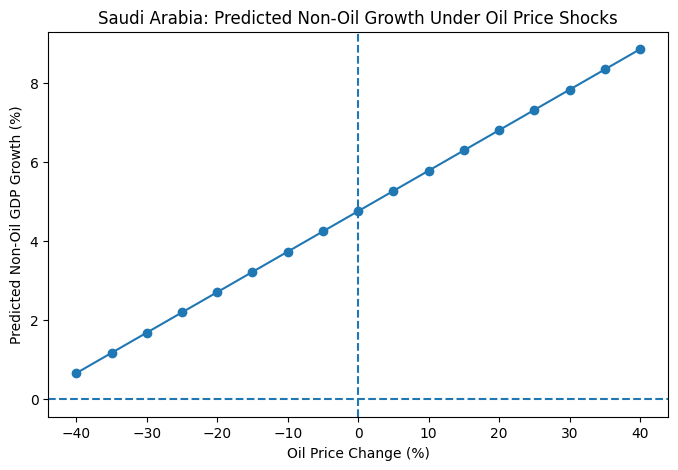

In [49]:
# Oil sensitivity curve


oil_range = np.arange(-40, 41, 5)

curve_df = pd.DataFrame({
    "OilChange": oil_range,
    "GovGrowth": baseline_gov,
    "FDI": baseline_fdi,
    "LagNonOilGrowth": baseline_lag
})

curve_df["Predicted_NonOilGrowth"] = (
    b["const"]
    + b["OilChange"] * curve_df["OilChange"]
    + b["GovGrowth"] * curve_df["GovGrowth"]
    + b["FDI"] * curve_df["FDI"]
    + b["LagNonOilGrowth"] * curve_df["LagNonOilGrowth"]
)

plt.figure(figsize=(8,5))
plt.plot(curve_df["OilChange"], curve_df["Predicted_NonOilGrowth"], marker="o")
plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Oil Price Change (%)")
plt.ylabel("Predicted Non-Oil GDP Growth (%)")
plt.title("Saudi Arabia: Predicted Non-Oil Growth Under Oil Price Shocks")
plt.show()

In [50]:
# Robustness Models

# Model 1: Oil only + lag
X1 = sm.add_constant(df[["OilChange", "LagNonOilGrowth"]])
m1 = sm.OLS(df["NonOilGrowth"], X1).fit()

# Model 2: Oil + gov + lag
X2 = sm.add_constant(df[["OilChange", "GovGrowth", "LagNonOilGrowth"]])
m2 = sm.OLS(df["NonOilGrowth"], X2).fit()

# Model 3: Oil + gov + FDI + lag
X3 = sm.add_constant(df[["OilChange", "GovGrowth", "FDI", "LagNonOilGrowth"]])
m3 = sm.OLS(df["NonOilGrowth"], X3).fit()

print("Model 1")
print(m1.summary())

print("Model 2")
print(m2.summary())

print("Model 3")
print(m3.summary())

Model 1
                            OLS Regression Results                            
Dep. Variable:           NonOilGrowth   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     25.66
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           2.30e-06
Time:                        21:09:04   Log-Likelihood:                -49.837
No. Observations:                  24   AIC:                             105.7
Df Residuals:                      21   BIC:                             109.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.9058      0.

In [51]:
# Split sample regression

split_year = 2016

df_pre = df[df["Year"] < split_year].copy()
df_post = df[df["Year"] >= split_year].copy()

def run_reg(data, label):
    Y = data["NonOilGrowth"]
    X = sm.add_constant(data[["OilChange", "GovGrowth", "FDI", "LagNonOilGrowth"]])
    result = sm.OLS(Y, X).fit()
    print(f"\n===== {label} =====")
    print(result.summary())
    return result

pre_model = run_reg(df_pre, f"Pre-{split_year}")
post_model = run_reg(df_post, f"{split_year} onwards")

print("\nOil coefficient comparison:")
print("Pre-period oil coef:", pre_model.params["OilChange"])
print("Post-period oil coef:", post_model.params["OilChange"])


===== Pre-2016 =====
                            OLS Regression Results                            
Dep. Variable:           NonOilGrowth   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     7.662
Date:                Fri, 17 Apr 2026   Prob (F-statistic):            0.00430
Time:                        21:09:07   Log-Likelihood:                -27.073
No. Observations:                  15   AIC:                             64.15
Df Residuals:                      10   BIC:                             67.69
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               

In [52]:
# VIF check

X_vif = df[["OilChange", "GovGrowth", "FDI", "LagNonOilGrowth"]].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

          Variable       VIF
0            const  4.086298
1        OilChange  2.410056
2        GovGrowth  2.738410
3              FDI  1.598015
4  LagNonOilGrowth  1.990108


In [53]:
# Correlation matrix

corr = df[["NonOilGrowth", "OilChange", "GovGrowth", "FDI", "LagNonOilGrowth"]].corr()
print(corr)

                 NonOilGrowth  OilChange  GovGrowth       FDI  LagNonOilGrowth
NonOilGrowth         1.000000   0.637747   0.594017  0.194705         0.440932
OilChange            0.637747   1.000000   0.456320  0.308840        -0.160404
GovGrowth            0.594017   0.456320   1.000000 -0.156433         0.443785
FDI                  0.194705   0.308840  -0.156433  1.000000         0.082543
LagNonOilGrowth      0.440932  -0.160404   0.443785  0.082543         1.000000


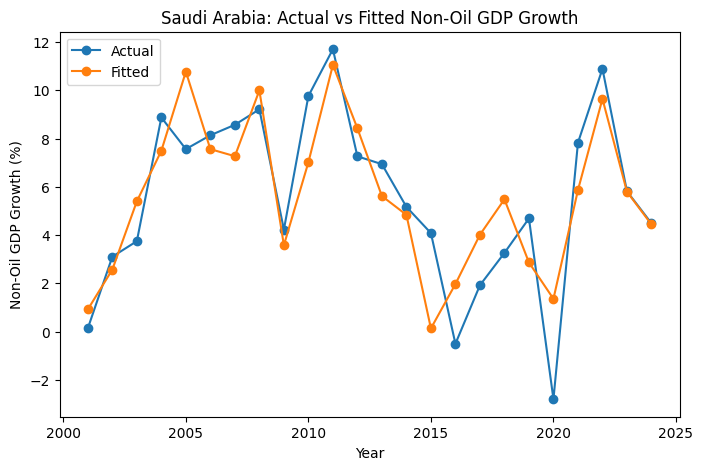

In [54]:
# Fitted vs actual

df["Fitted"] = model.fittedvalues

plt.figure(figsize=(8,5))
plt.plot(df["Year"], df["NonOilGrowth"], marker="o", label="Actual")
plt.plot(df["Year"], df["Fitted"], marker="o", label="Fitted")
plt.xlabel("Year")
plt.ylabel("Non-Oil GDP Growth (%)")
plt.title("Saudi Arabia: Actual vs Fitted Non-Oil GDP Growth")
plt.legend()
plt.show()

In [55]:
# Scenario predictions with confidence intervals

scenario_X = scenarios[["OilChange", "GovGrowth", "FDI", "LagNonOilGrowth"]]
scenario_X = sm.add_constant(scenario_X, has_constant="add")

pred = model.get_prediction(scenario_X)
pred_summary = pred.summary_frame(alpha=0.05)

scenario_results = pd.concat([scenarios[["Scenario"]], pred_summary], axis=1)
print(scenario_results)

                              Scenario      mean   mean_se  mean_ci_lower  \
0                             Oil -10%  3.729818  0.625348       2.420950   
1                             Oil -20%  2.706448  0.819962       0.990247   
2                             Oil -30%  1.683078  1.036925      -0.487232   
3                    Oil -20%, Gov -5%  2.943438  0.846960       1.170731   
4                   Oil -30%, Gov -10%  2.013855  1.105390      -0.299753   
5  Recovery: Oil +15%, Gov +3%, FDI +1  5.976976  0.667765       4.579328   

   mean_ci_upper  obs_ci_lower  obs_ci_upper  
0       5.038686     -0.940596      8.400232  
1       4.422649     -2.094071      7.506967  
2       3.853388     -3.297874      6.664030  
3       4.716145     -1.877571      7.764447  
4       4.327463     -3.031184      7.058894  
5       7.374624      1.280908     10.673044  
